In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
def calculate_gini(values):
    """Calculates the Gini coefficient for a given array of values."""
    n = len(values)
    if n == 0 or np.sum(values) == 0:
        return 0.0
    sorted_vals = np.sort(values)
    idx_arr = np.arange(1, n + 1)
    return np.sum((2 * idx_arr - n - 1) * sorted_vals) / (n * np.sum(sorted_vals))

In [4]:
def get_threshold_coords(x_arr, y_arr, thresholds):
    """Finds the (x, y, index) coordinates where y_arr crosses the given thresholds."""
    coords = []
    for thresh in thresholds:
        idx = np.argmax(y_arr >= thresh)
        coords.append((x_arr[idx], y_arr[idx], idx + 1))
    return coords

In [5]:
def apply_plot_aesthetics(ax, x_label, y_label):
    font_labels = {'weight': 'bold', 'size': 12}
    ax.set_xlabel(x_label, fontdict=font_labels)
    ax.set_ylabel(y_label, fontdict=font_labels)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 105)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    sns.despine(ax=ax)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(10)
    leg = ax.legend(loc='lower right', fancybox=True, shadow=True, frameon=True, prop={'weight': 'bold', 'size': 10})
    leg.get_frame().set_edgecolor('black')

In [6]:
def plot_cumulative_curve(x, y, coords, thresholds, palette, line_color, x_label, y_label, legend_prefix, out_file):
    """Generates and saves a standardized cumulative line plot."""
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(x, y, color=line_color, linewidth=2.0, label='_nolegend_')

    for i, thresh in enumerate(thresholds):
        cx, cy, _ = coords[i]
        c = palette[i]
        ax.hlines(y=cy, xmin=0, xmax=cx, colors=c, linestyles='dotted', alpha=0.6, linewidth=1.5)
        
        # Determine the label string cleanly
        target_name = x_label.replace('% ', '')
        ax.vlines(x=cx, ymin=0, ymax=cy, colors=c, linestyles='dashed', linewidth=2.0, 
                  label=f'{thresh}% {legend_prefix} = Top {cx:.2f}% {target_name}')
        ax.plot(cx, cy, marker='o', color=c, markerfacecolor='none', markeredgewidth=2.0, markersize=8)

    apply_plot_aesthetics(ax, x_label, y_label)
    plt.tight_layout()
    plt.savefig(out_file, bbox_inches='tight', format='pdf')
    plt.show()
    plt.close(fig)

In [7]:
cols = ['JobID', 'JobID_base', 'JobID_suffix', 'JobID_step', 'JobID_type', 
        'User', 'ConsumedEnergyRaw', 'ReqNodes', 'Elapsed']
df = pd.read_parquet("data/slurm-preprocessed.parquet", columns=cols)

total_raw_rows = len(df)
print(f"Ingested {total_raw_rows:,} raw job/step accounting records.")

Ingested 10,888,402 raw job/step accounting records.


In [8]:
df['User'] = df['User'].fillna('System_Unknown')

In [9]:
compute_only = df[~df['JobID'].astype(str).str.endswith('.batch')]
unique_executions = compute_only.drop_duplicates(subset=['JobID'])

In [10]:
user_counts = unique_executions['User'].value_counts(dropna=False).sort_values(ascending=False)
total_raw_jobs = user_counts.sum()
total_raw_users = len(user_counts)

In [11]:
cum_job_volume_pct = user_counts.cumsum() / total_raw_jobs * 100
user_vol_percent = np.arange(1, total_raw_users + 1) / total_raw_users * 100

gini_user_volume = calculate_gini(user_counts.values)
print(f"  - User Raw Allocation Volume Gini Coefficient: {gini_user_volume:.4f}")

  - User Raw Allocation Volume Gini Coefficient: 0.9521


In [12]:
df['ConsumedEnergyRaw'] = pd.to_numeric(df['ConsumedEnergyRaw'], errors='coerce')
df['ReqNodes'] = pd.to_numeric(df['ReqNodes'], errors='coerce').fillna(1)
df['Elapsed_Cleaned'] = df['Elapsed'].astype(str).str.replace(r'^(\d+)-', r'\1 days ', regex=True)
df['Elapsed_Seconds'] = pd.to_timedelta(df['Elapsed_Cleaned'], errors='coerce').dt.total_seconds().fillna(0)

df['Parent_JobID'] = np.where(
    df['JobID_suffix'].notna() & (df['JobID_suffix'] != '') & (df['JobID_suffix'] != 'None'),
    df['JobID_base'].astype(str) + "_" + df['JobID_suffix'].astype(str),
    df['JobID_base'].astype(str)
)

fused = df.groupby('Parent_JobID').agg({
    'User': 'first',
    'ConsumedEnergyRaw': 'max',
    'ReqNodes': 'max',
    'Elapsed_Seconds': 'max'
}).reset_index().rename(columns={'Parent_JobID': 'JobID'})

total_fused_jobs = len(fused)
print(f"Fused into {total_fused_jobs:,} unique top-level physical Job profiles.")

Fused into 4,747,578 unique top-level physical Job profiles.


In [13]:
mask_nan = fused['ConsumedEnergyRaw'].isna()
mask_zero = (fused['ConsumedEnergyRaw'] <= 0) & ~mask_nan
mask_runtime = (fused['ConsumedEnergyRaw'] > 0) & (fused['Elapsed_Seconds'] <= 0)

fused['Avg_Power_Watts_Per_Node'] = np.where(
    (fused['Elapsed_Seconds'] > 0) & (fused['ReqNodes'] > 0),
    fused['ConsumedEnergyRaw'] / (fused['Elapsed_Seconds'] * fused['ReqNodes']),
    0.0
)
mask_power_violation = (fused['ConsumedEnergyRaw'] > 0) & (fused['Elapsed_Seconds'] > 0) & (fused['Avg_Power_Watts_Per_Node'] > 5000.0)

faulty_mask = mask_nan | mask_zero | mask_runtime | mask_power_violation
total_faulty = faulty_mask.sum()
print(f"  - Total Faulty/Glitched Records Isolated: {total_faulty:,} ({(total_faulty/total_fused_jobs)*100:.2f}%)")

df_clean = fused[~faulty_mask].copy()
df_clean['Energy_kWh'] = df_clean['ConsumedEnergyRaw'] / 3600000.0

total_clean_jobs = len(df_clean)
total_clean_users = df_clean['User'].nunique()
total_energy_consumed = df_clean['Energy_kWh'].sum()

print(f"Clean, verified dataset size: {total_clean_jobs:,} jobs | {total_clean_users:,} users.")
print(f"Total cluster-wide verified energy consumption: {total_energy_consumed:,.2f} kWh")

  - Total Faulty/Glitched Records Isolated: 552,582 (11.64%)
Clean, verified dataset size: 4,194,996 jobs | 605 users.
Total cluster-wide verified energy consumption: 2,669,579.82 kWh


In [14]:
# Job Energy Distribution
jobs_sorted = df_clean.sort_values(by='Energy_kWh', ascending=False).reset_index(drop=True)
jobs_sorted['Cum_Energy_Pct'] = (jobs_sorted['Energy_kWh'].cumsum() / total_energy_consumed) * 100
jobs_sorted['Cum_Jobs_Pct'] = (np.arange(1, total_clean_jobs + 1) / total_clean_jobs) * 100

gini_jobs = calculate_gini(jobs_sorted['Energy_kWh'].values)
print(f"  - Job Energy Gini Coefficient: {gini_jobs:.4f}")

  - Job Energy Gini Coefficient: 0.9335


In [15]:
# User Energy Distribution
user_energy = df_clean.groupby('User')['Energy_kWh'].sum().reset_index()
users_sorted = user_energy.sort_values(by='Energy_kWh', ascending=False).reset_index(drop=True)
users_sorted['Cum_Energy_Pct'] = (users_sorted['Energy_kWh'].cumsum() / total_energy_consumed) * 100
users_sorted['Cum_Users_Pct'] = (np.arange(1, total_clean_users + 1) / total_clean_users) * 100

gini_users = calculate_gini(users_sorted['Energy_kWh'].values)
print(f"  - User Energy Gini Coefficient: {gini_users:.4f}")

  - User Energy Gini Coefficient: 0.8977


In [16]:
thresholds = [70, 80, 90, 95, 99]

job_energy_coords = get_threshold_coords(jobs_sorted['Cum_Jobs_Pct'].values, jobs_sorted['Cum_Energy_Pct'].values, thresholds)
user_energy_coords = get_threshold_coords(users_sorted['Cum_Users_Pct'].values, users_sorted['Cum_Energy_Pct'].values, thresholds)
user_volume_coords = get_threshold_coords(user_vol_percent, cum_job_volume_pct.values, thresholds)

top_pcts = [0.1, 1.0, 5.0, 10.0]
benchmarks_energy, benchmarks_volume = [], []

for pct in top_pcts:
    idx_e_j = max(0, int(np.ceil(total_clean_jobs * (pct / 100.0))) - 1)
    idx_e_u = max(0, int(np.ceil(total_clean_users * (pct / 100.0))) - 1)
    idx_v_u = max(0, int(np.ceil(total_raw_users * (pct / 100.0))) - 1)
    
    benchmarks_energy.append({
        "Top Tier Group": f"Top {pct}%",
        "Jobs Energy Share (%)": f"{jobs_sorted['Cum_Energy_Pct'].values[idx_e_j]:.2f}%",
        "Users Energy Share (%)": f"{users_sorted['Cum_Energy_Pct'].values[idx_e_u]:.2f}%"
    })
    
    benchmarks_volume.append({
        "Top Tier Group": f"Top {pct}% Users",
        "Raw Job Volume Share (%)": f"{cum_job_volume_pct.values[idx_v_u]:.2f}%",
        "Users Count": f"{idx_v_u + 1:,}"
    })

In [17]:
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)
palette = sns.color_palette("colorblind", len(thresholds))

out_job_energy = "cumulative_job_energy_plot.pdf"
out_user_energy = "cumulative_user_energy_plot.pdf"
out_user_volume = "cumulative_user_jobs_plot.pdf"

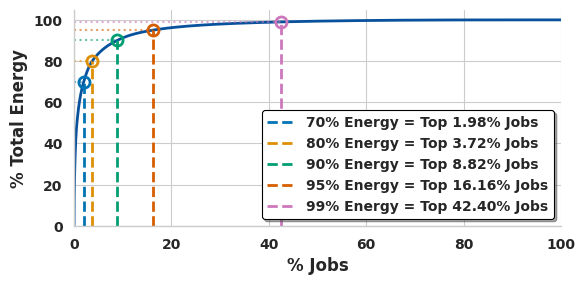

In [18]:
plot_cumulative_curve(jobs_sorted['Cum_Jobs_Pct'], jobs_sorted['Cum_Energy_Pct'], job_energy_coords, 
                      thresholds, palette, '#08519c', '% Jobs', '% Total Energy', 'Energy', out_job_energy)

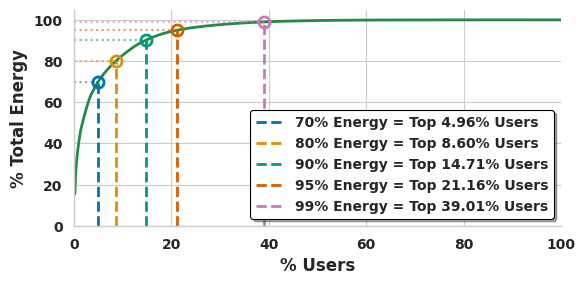

In [19]:
plot_cumulative_curve(users_sorted['Cum_Users_Pct'], users_sorted['Cum_Energy_Pct'], user_energy_coords, 
                      thresholds, palette, '#238b45', '% Users', '% Total Energy', 'Energy', out_user_energy)

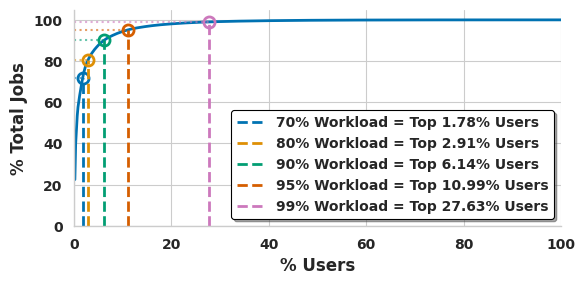

In [20]:
plot_cumulative_curve(user_vol_percent, cum_job_volume_pct.values, user_volume_coords, 
                      thresholds, palette, '#0072B2', '% Users', '% Total Jobs', 'Workload', out_user_volume)

In [21]:
df_thresh_energy = pd.DataFrame([{
    "Target %": f"{thresh}%",
    "Jobs Required (%)": f"{job_energy_coords[i][0]:.4f}%",
    "Jobs Count": f"{job_energy_coords[i][2]:,}",
    "Users Required (%)": f"{user_energy_coords[i][0]:.2f}%",
    "Users Count": f"{user_energy_coords[i][2]:,}"
} for i, thresh in enumerate(thresholds)])

df_thresh_volume = pd.DataFrame([{
    "Target Workload %": f"{thresh}%",
    "Users Required (%)": f"{user_volume_coords[i][0]:.2f}%",
    "Users Count": f"{user_volume_coords[i][2]:,}"
} for i, thresh in enumerate(thresholds)])

In [22]:
print(f"Total Raw Allocations Processed:** {total_raw_jobs:,} steps/executions.")
print(f"Unique Physical Job Profiles (Fused):** {total_fused_jobs:,}")
print(f"Faulty Sensor Records Filtered:** {total_faulty:,} ({(total_faulty/total_fused_jobs*100):.2f}% of jobs)")
print(f"Clean Dataset Target Scope:** {total_clean_jobs:,} base jobs | **{total_energy_consumed:,.2f} kWh**\n")

print("Gini Coefficients approaching 1.0 indicate absolute concentration:\n")
print(f"- **Raw Job Volume per User (Gini):** **{gini_user_volume:.4f}**")
print(f"- **Physical Energy per User (Gini):** **{gini_users:.4f}**")
print(f"- **Physical Energy per Job (Gini):** **{gini_jobs:.4f}**\n")

print(df_thresh_energy.to_markdown(index=False) + "\n")

print(df_thresh_volume.to_markdown(index=False) + "\n")

print("### Energy Distribution")
print(pd.DataFrame(benchmarks_energy).to_markdown(index=False) + "\n")
print("### Workload Volume Distribution")
print(pd.DataFrame(benchmarks_volume).to_markdown(index=False) + "\n")

Total Raw Allocations Processed:** 6,125,003 steps/executions.
Unique Physical Job Profiles (Fused):** 4,747,578
Faulty Sensor Records Filtered:** 552,582 (11.64% of jobs)
Clean Dataset Target Scope:** 4,194,996 base jobs | **2,669,579.82 kWh**

Gini Coefficients approaching 1.0 indicate absolute concentration:

- **Raw Job Volume per User (Gini):** **0.9521**
- **Physical Energy per User (Gini):** **0.8977**
- **Physical Energy per Job (Gini):** **0.9335**

| Target %   | Jobs Required (%)   |   Jobs Count | Users Required (%)   |   Users Count |
|:-----------|:--------------------|-------------:|:---------------------|--------------:|
| 70%        | 1.9834%             |       83,202 | 4.96%                |            30 |
| 80%        | 3.7192%             |      156,022 | 8.60%                |            52 |
| 90%        | 8.8242%             |      370,175 | 14.71%               |            89 |
| 95%        | 16.1577%            |      677,815 | 21.16%               |        

In [23]:
top_n = 0.05
top_n_vol_count = max(1, int(len(user_counts) * top_n))
top_n_energy_count = max(1, int(len(users_sorted) * top_n))
top_n_jobs_count = max(1, int(len(jobs_sorted) * top_n))

top_volume_users = set(user_counts.index[:top_n_vol_count])
top_energy_users = set(users_sorted['User'].iloc[:top_n_energy_count])
top_job_energy_users = set(jobs_sorted['User'].iloc[:top_n_jobs_count].unique())

overlap_all_three = top_volume_users.intersection(top_energy_users).intersection(top_job_energy_users)

print(f"Total Unique Users in Top Volume: {len(top_volume_users)}")
print(f"Total Unique Users in Top Energy: {len(top_energy_users)}")
print(f"Total Unique Users in Top Job Energy: {len(top_job_energy_users)}")
print("-" * 40)
print(f"Users consistently in all 3 top tiers: {len(overlap_all_three)}")
print(f"Users in Volume & Total Energy overlap: {len(top_volume_users.intersection(top_energy_users))}")

Total Unique Users in Top Volume: 30
Total Unique Users in Top Energy: 30
Total Unique Users in Top Job Energy: 464
----------------------------------------
Users consistently in all 3 top tiers: 12
Users in Volume & Total Energy overlap: 12
